In [2]:
import copy, math 
import numpy as np 
import matplotlib.pyplot as plt
np.set_printoptions(precision=2) #reduce display precision on numpy 

# Problem Statement 

You will use the motivating example of housing price prediction 

|Size (sqft) |Number of Bedrooms | Number of floors | Age of Home | Price (1000s dollars)|
|------------|-------------------|------------------|-------------|--------------|
|2104           |        5             |     1            | 45          | 460    |
|1416           |        3             |     2            | 40          | 232    |

In [5]:
X_train = np.array([[2104, 5, 1, 45], 
                    [1416, 3, 2, 40], 
                    [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])

In [12]:
# data is stored in numpy array/matrix 
print(f"X Shape: {X_train.shape}, X type:{type(X_train)}")
print(X_train)
print(f"y shape: {y_train.shape}, Y type:{type(y_train)}") 
print(y_train) 

X Shape: (3, 4), X type:<class 'numpy.ndarray'>
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
y shape: (3,), Y type:<class 'numpy.ndarray'>
[460 232 178]


In [10]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"w_init shape: {w_init.shape}, b_init type: {type(b_init)}")

w_init shape: (4,), b_init type: <class 'float'>


# 3 Model Prediction With Multiple Variables 

$$ f_{\mathbf{w},b}(\mathbf{x}) =  w_0x_0 + w_1x_1 +... + w_{n-1}x_{n-1} + b \tag{1}$$
or in vector notation:
$$ f_{\mathbf{w},b}(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b  \tag{2} $$ 
where $\cdot$ is a vector `dot product`

In [13]:
def predict_single_loop(x, w, b): 
    n = x.shape[0]
    p = 0
    for i in range(n): 
        p_i = x[i] * w[i]
        p = p + p_i 
    p = p + b
    return p

In [17]:
x_vec = X_train[0,:]
print(f"x_vec value: {x_vec}")

# make a prediction 
f_wb = predict_single_loop(x_vec, w_init, b_init) 
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

x_vec value: [2104    5    1   45]
f_wb shape (), prediction: 459.9999976194083


## 3.2 Single Prediction, vector

Noting that equation (1) can be implemented using the dot product as in (2) above.

In [19]:
def predict(x, w, b): 
    p = np.dot(x, w) + b
    return p

In [20]:
x_vec = X_train[0,:]
print(f"x_vec value: {x_vec}")

# make a prediction 
f_wb = predict_single_loop(x_vec, w_init, b_init) 
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

x_vec value: [2104    5    1   45]
f_wb shape (), prediction: 459.9999976194083


## 4 Compute Cost With Multiple Variables 

The equation for the cost function with multiple variables $J(\mathbf{w},b)$ is:
$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})^2 \tag{3}$$ 
where:
$$ f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot \mathbf{x}^{(i)} + b  \tag{4} $$ 

In [21]:
def compute_cost (X, y, w, b): 
    m = X.shape[0]
    cost = 0.0 
    for i in range(m): 
        f_wb_i = np.dot(X[i], w) + b 
        cost = cost + (f_wb_i - y[i])**2 
    cost = (1/(2*m)) * cost 
    return cost 

In [22]:
cost = compute_cost(X_train, y_train, w_init, b_init)
print(f'Cost at optimal w: {cost}')

Cost at optimal w: 1.5578904045996674e-12


# 5 Gradient Descent With Multiple Variables
Gradient descent for multiple variables:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline\;
& w_j = w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{5}  \; & \text{for j = 0..n-1}\newline
&b\ \ = b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b}  \newline \rbrace
\end{align*}$$

where, n is the number of features, parameters $w_j$,  $b$, are updated simultaneously and where  

$$
\begin{align}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)} \tag{6}  \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \tag{7}
\end{align}
$$

In [24]:
def compute_gradient(X, y, w, b): 
    m, n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0

    for i in range(m): 
        err = (np.dot(X[i], w) + b) - y[i]
        for j in range(n): 
            dj_dw[j] = dj_dw[j] + err * X[i, j]
        dj_db = dj_db + err
    dj_dw = dj_dw / m 
    dj_db = dj_db / m

    return dj_db, dj_dw

In [27]:
#Compute and display gradient 
tmp_dj_db, tmp_dj_dw = compute_gradient(X_train, y_train, w_init, b_init)
print(f'dj_db at initial w, b: {tmp_dj_db}')
print(f'dj_dw at initial w, b: {tmp_dj_dw}')

dj_db at initial w, b: -1.6739251122999121e-06
dj_dw at initial w, b: [-2.73e-03 -6.27e-06 -2.22e-06 -6.92e-05]


In [29]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    J_history = []
    w = copy.deepcopy(w_in)
    b = b_in 

    for i in range(num_iters):
        dj_db, dj_dw = gradient_function(X, y, w, b) 

        w = w - alpha * dj_dw 
        b = b - alpha * dj_db 

        if i < 100000: 
            J_history.append(cost_function(X, y, w, b))

        if i % math.ceil(num_iters / 10) == 0: 
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}     ") 
    return w, b, J_history

In [36]:
#initialize parameters 
initial_w = np.zeros_like(w_init)
initial_b = 0.

iterations = 1000
alpha = 5.0e-7

w_final, b_final, J_hist = gradient_descent(X_train, y_train, initial_w, initial_b, 
                                            compute_cost, compute_gradient, 
                                            alpha, iterations) 
print(f"b, w found by gradient descent: {b_final:0.2f}, {w_final} ") 
m,_ = X_train.shape
for i in range(m): 
    print(f"prediction: {np.dot(X_train[i], w_final) + b_final:0.2f}, target_value: {y_train[i]}")

Iteration    0: Cost  2529.46     
Iteration  100: Cost   695.99     
Iteration  200: Cost   694.92     
Iteration  300: Cost   693.86     
Iteration  400: Cost   692.81     
Iteration  500: Cost   691.77     
Iteration  600: Cost   690.73     
Iteration  700: Cost   689.71     
Iteration  800: Cost   688.70     
Iteration  900: Cost   687.69     
b, w found by gradient descent: -0.00, [ 0.2   0.   -0.01 -0.07] 
prediction: 426.19, target_value: 460
prediction: 286.17, target_value: 232
prediction: 171.47, target_value: 178


NameError: name 'J_hist' is not defined

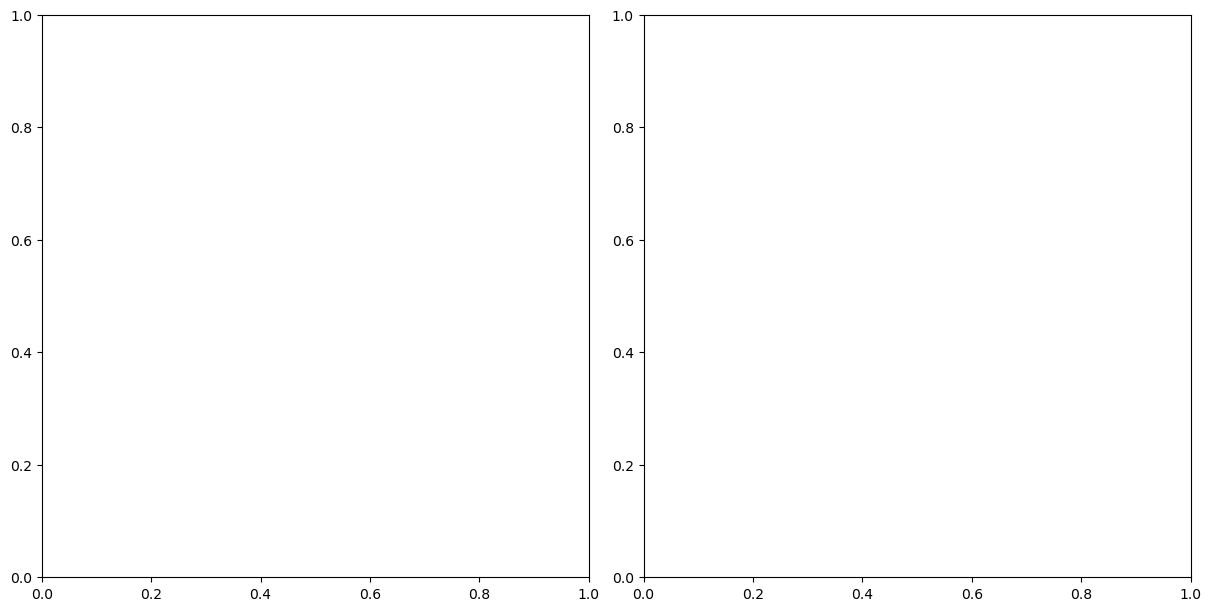

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 6))
ax1.plot(J_hist)